<a href="https://colab.research.google.com/github/sushma33808/TNSpython/blob/main/Spam_Mail_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 1.0
Prediction: spam


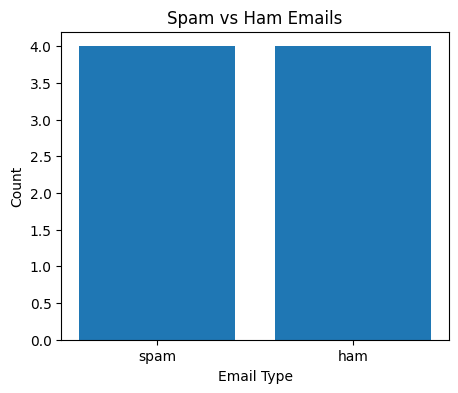

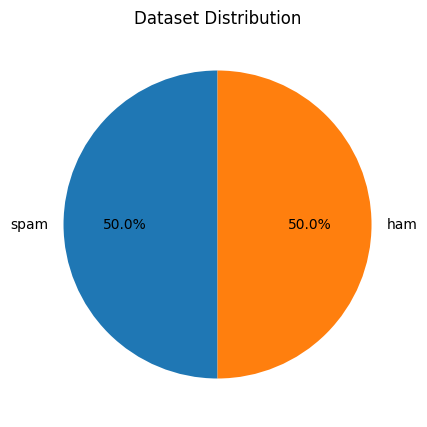

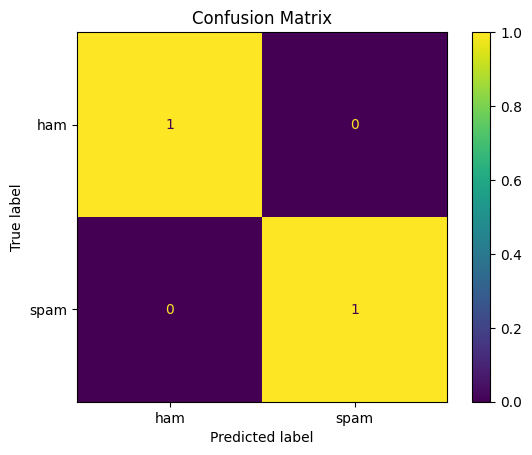

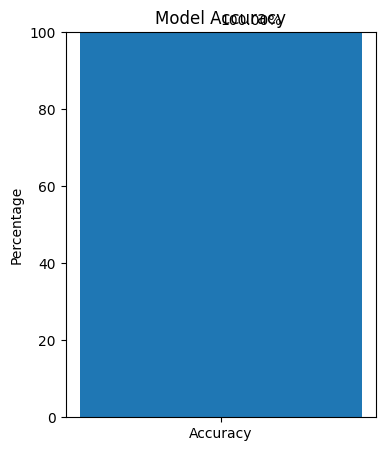

In [5]:
# Spam Mail Detection using Machine Learning

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Sample dataset
data = {
    'Email': [
        'Congratulations! You won a lottery',
        'Claim your free gift now',
        'Meeting at 10 AM tomorrow',
        'Project submission deadline is today',
        'Win cash prizes now',
        'Let us discuss the project',
        'Exclusive offer just for you',
        'Can we schedule a meeting?'
    ],
    'Label': [
        'spam',
        'spam',
        'ham',
        'ham',
        'spam',
        'ham',
        'spam',
        'ham'
    ]
}

df = pd.DataFrame(data)

# Features and Labels
X = df['Email']
y = df['Label']

# Convert text into numerical data
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = MultinomialNB()
model.fit(X_train, y_train)

# Prediction
prediction = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, prediction))

# Test with a new email
new_email = ["Congratulations! Claim your free cash prize now"]
new_email_vector = vectorizer.transform(new_email)

result = model.predict(new_email_vector)

print("Prediction:", result[0])

# Count spam and ham emails
counts = df['Label'].value_counts()

# Plot
plt.figure(figsize=(5,4))
plt.bar(counts.index, counts.values)
plt.title("Spam vs Ham Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(5,5))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Dataset Distribution")
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=model.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

accuracy = accuracy_score(y_test, prediction)

plt.figure(figsize=(4,5))
plt.bar(["Accuracy"], [accuracy * 100])
plt.ylim(0,100)
plt.ylabel("Percentage")
plt.title("Model Accuracy")
plt.text(0, accuracy*100 + 2, f"{accuracy*100:.2f}%")
plt.show()